# Ex.No.11 - K-Means Clustering

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 07/04/2026_

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Load Dataset
df = pd.read_csv(r"D:\VI\FOML\Datasets\penguins.csv")

X = df.drop("sex", axis=1)   # remove label column

print("Shape :", X.shape)
X.head()

Shape : (332, 4)


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181,3750
1,39.5,17.4,186,3800
2,40.3,18.0,195,3250
3,36.7,19.3,193,3450
4,39.3,20.6,190,3650


In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

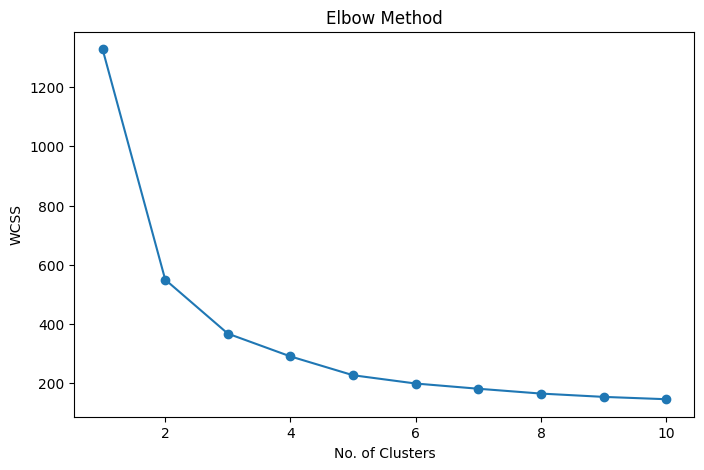

In [ ]:
# Elbow Method
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Train Final Model
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,Cluster
0,39.1,18.7,181,3750,MALE,0
1,39.5,17.4,186,3800,FEMALE,0
2,40.3,18.0,195,3250,FEMALE,0
3,36.7,19.3,193,3450,FEMALE,0
4,39.3,20.6,190,3650,MALE,0


In [ ]:
# Silhouette Score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score :", round(score,3))

Silhouette Score : 0.531


In [ ]:
# Cluster Count
print(df["Cluster"].value_counts())

Cluster
0    213
1    119
Name: count, dtype: int64


[[  42.03943662   18.35774648  191.89201878 3711.50234742]
 [  47.56806723   14.99663866  217.23529412 5092.43697479]]


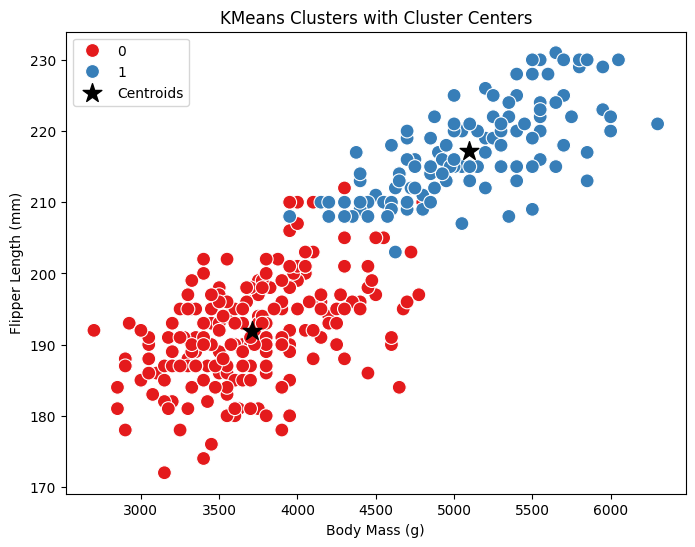

In [ ]:
# Visualization
plt.figure(figsize=(8,6))

# Scatter points
sns.scatterplot(
    x=df["body_mass_g"],
    y=df["flipper_length_mm"],
    hue=df["Cluster"],
    palette="Set1",
    s=100
)

# Get centers from scaled data -> inverse transform
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print(centers)

# body_mass_g index = 3
# flipper_length_mm index = 2

plt.scatter(
    centers[:,3],          # body_mass_g
    centers[:,2],          # flipper_length_mm
    c="black",
    s=200,
    marker="*",
    label="Centroids"
)

plt.title("KMeans Clusters with Cluster Centers")
plt.xlabel("Body Mass (g)")
plt.ylabel("Flipper Length (mm)")
plt.legend()
plt.show()

In [ ]:
# Custom Data Prediction
custom_data = pd.DataFrame([{
    "culmen_length_mm":45.2,
    "culmen_depth_mm":17.1,
    "flipper_length_mm":210,
    "body_mass_g":5000
}])

custom_scaled = scaler.transform(custom_data)
pred_cluster = kmeans.predict(custom_scaled)

print("Predicted Cluster :", pred_cluster[0])

Predicted Cluster : 1
